#### **Problem Statement :**

- Fine-tuning a language model involves training or adjusting the parameters of a pre-trained model for a specific task or domain.

- Fine tuning involves adjusting the weights of some or all layers of the pre-trained model for the specific task.

- In **Supervised fine-tuning**, a model is trained on a task-specific labeled dataset where each datapoint has a label or right answer. The model learns to adjust its parameters to ensure the labels are predicted accurately.

- Types of Supervised fine-tuning : Basic hyperparameter tuning, task specific fine tuning, transfer learning, few-shot learning, multi-task learning.

- **Reinforcement Learning with Human Feedback** is based on training the language model through interactions with human feedback. Through incorporation of human feedback into the learning process, RLHF enhances model performance leading to more accurate responses.  


- Types of RLHF : Reward model training, proximal policy optimization, comparative ranking, preference learning

- PEFT : **Parameter efficient fine tuning** focuses on training a subset of the pretrained model parameters.

- Types of PEFT  : LoRA, QLoRA

- Hu, Zhiqiang, et al. "LLM-Adapters: An Adapter Family for Parameter-Efficient Fine-Tuning of Large Language Models." arXiv preprint arXiv:2304.01933 (2023).

- https://doi.org/10.48550/arXiv.2312.12148

- https://huggingface.co/datasets/Falah/sentiments-dataset-381-classes

- https://towardsdatascience.com/fine-tuning-large-language-models-llms-23473d763b91

- https://www.turing.com/resources/finetuning-large-language-models


#### **Installing Dependencies**

In [ ]:
# Installing the dependencies : datasets, transformers, accelerate, evaluate
# Pinned versions (tested Oct 2026) so this notebook keeps working on Google Colab
!pip install -q transformers==4.44.2 peft==0.12.0 accelerate==0.34.2 datasets==2.21.0 evaluate==0.4.6 bitsandbytes==0.50.2 wordcloud
# !pip install datasets transformers -q   # (replaced by the pinned install above)
# !pip install accelerate -q   # (replaced by the pinned install above)
# !pip install evaluate -q   # (replaced by the pinned install above)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.7/536.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 13.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.8/134.8 kB 15.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 280.0/280.0 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.4 MB/s eta 0:00:00


#### **Importing required libraries**

In [ ]:
# Importing pandas, datasets, wordcloud, AutoTokenizer, evaluate, Trainer, TrainingArguments
from datasets import load_dataset, Dataset # load_dataset from the dataset repository # Dataset to load a dataset from a pandas dataframe
import pandas as pd # Data manipulation, data preprocessing and data cleaning
import numpy as np # numpy for mathematical function
from wordcloud import WordCloud, STOPWORDS # Data visualization using WordCloud
from transformers import AutoTokenizer # AutoTokenizer : generic tokenizer class from HuggingFace for appropriately tokenized words
import torch # PyTorch
import evaluate # Evaluate from HuggingFace
from transformers import TrainingArguments, Trainer # TrainingArguments for hyperparameters and Trainer object for finetuning.

In [ ]:
# Securely storing the HF_API KEY
# https://huggingface.co/settings/tokens
from google.colab import userdata
HF_TOKEN = userdata.get("HF_TOKEN")

In [ ]:
# Check if PyTorch is using gpu
dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
# Loading the amazon_reviews_mobile_electronics dataset from HuggingFace using load_dataset() method
dataset = load_dataset("rkf2778/amazon_reviews_mobile_electronics")
dataset

DatasetDict({
    train: Dataset({
        features: ['customer_id', 'product_title', 'star_rating', 'review_body', 'product_id', 'star_rating_label'],
        num_rows: 68904
    })
    test: Dataset({
        features: ['customer_id', 'product_title', 'star_rating', 'review_body', 'product_id', 'star_rating_label'],
        num_rows: 17227
    })
})

#### **Data cleaning and analysis of the text reviews**

In [ ]:
# Converting the dataset to a Pandas DataFrame
df = pd.DataFrame(dataset['train'])
df.head()

,customer_id,product_title,star_rating,review_body,product_id,star_rating_label
0,28471074,Sprint Universal Folding Portable Mini Stereo ...,5,Item was as discribed ; was shipped fast and f...,B005BHGZ6A,positive
1,1958232,"iXCC Lightning Cable 3ft, iPhone charger, for ...",5,Came in perfect. Works perfectly,B00J46XO9U,positive
2,49126521,Sennheiser HMEC 250 NoiseGard Pilot Headset,2,"Good quality, came with out the extra boom mic...",B003JW0C7C,negative
3,46531276,"M-Edge Touring Sleeve for Kindle (Fits 6"" Disp...",5,I do not like reading my Kindle in a case so t...,B002GXCQ3S,positive
4,4487344,iPod Touch 5th 6th Generation Case MyTurtle TM...,5,The case came 3 days after I ordered it. It fi...,B00TGI0EUI,positive


In [ ]:
# Data Cleaning to drop null values
df.dropna(inplace = True)
df.isna().sum()

customer_id          0
product_title        0
star_rating          0
review_body          0
product_id           0
star_rating_label    0
dtype: int64

In [ ]:
# Extracting distinct categoires in 'star_rating_label' column in the dataframe
df.star_rating_label.unique()

array(['positive', 'negative'], dtype=object)

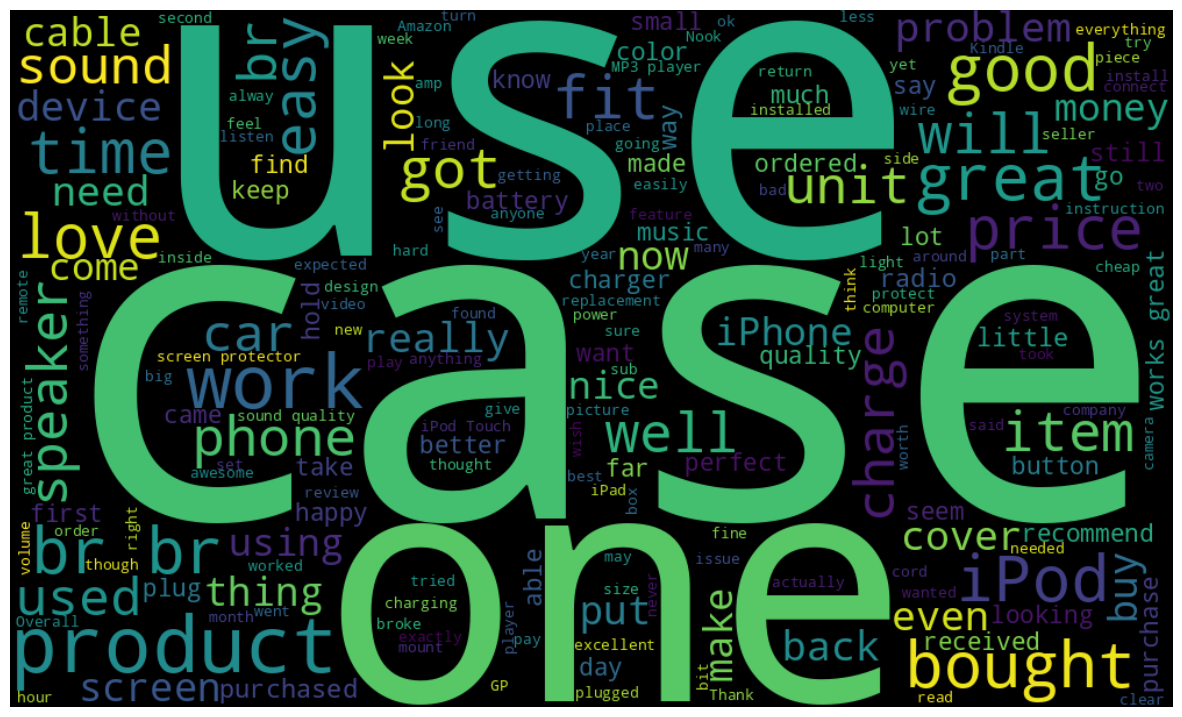

In [ ]:
# Word Cloud to visualize the df.review_body column
import matplotlib.pyplot as plt
text = "".join(i for i in df.review_body)
stop_words = set(STOPWORDS)
wordcloud = WordCloud(stopwords = stop_words, background_color= "black", width=1000, height =600).generate(text)
plt.figure(figsize=(15, 10))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
# Encoding the star_rating_label column using df.replace() method

df['star_rating_label'].replace({"positive":1, "negative":0}, inplace = True)
df.dtypes

customer_id           int64
product_title        object
star_rating           int64
review_body          object
product_id           object
star_rating_label     int64
dtype: object

In [ ]:
# Creating a df_1 dataframe with `star_rating_label` and `review_body` column
df_1 = df[['star_rating_label','review_body']]
df_1.columns = ['label','text']

#### **Convert Pandas DataFrame to HuggingFace Dataset**

In [ ]:
# Loading the Dandas dataframe to a dataset format using dataset.from_pandas() method
dataset = Dataset.from_pandas(df_1)

In [ ]:
# Creating a train-evaluation split with a ratio of 90% for training data and 10% for evaluation set
dataset_ = dataset.train_test_split(test_size = 0.1)

#### **Tokenizer**

- Tokenizer splits the sequence into tokens available in the tokenizer vocabulary

- Tokens are either words or subwords. `TESLA` as an example, is split into "Te", '##sla'. To indicate these are not separate words, a double hash prefix is added.

- These tokens can be converted into IDs, understandable by the model.

- The tokenizer returns a dictionary, with all the arguments required for its corresponding model to work properly.

- https://huggingface.co/docs/transformers/en/glossary

In [ ]:
# Example : Tokenization using the BERT Tokenizer, which is a word-piece tokenizer

from transformers import BertTokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-cased")
sequence = "Tesla T4 gpu supports 16 GB of memory"
tokenized_sequence = tokenizer.tokenize(sequence)
print(tokenized_sequence)

['Te', '##sla', 'T', '##4', 'g', '##pu', 'supports', '16', 'GB', 'of', 'memory']


In [ ]:
# Input_ids
inputs = tokenizer(sequence)
inputs

{'input_ids': [101, 12008, 26597, 157, 1527, 176, 16091, 6253, 1479, 17909, 1104, 2962, 102], 'token_type_ids': [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [ ]:
# The token indices are under the key input_ids
encoded_sequence = inputs['input_ids']

In [ ]:
# decoded sequence : using the previous sequence of IDs, showing the tokenizer has added special tokens - [CLS], [SEP]

decoded_sequence = tokenizer.decode(encoded_sequence)
decoded_sequence

'[CLS] Tesla T4 gpu supports 16 GB of memory [SEP]'

#### **AutoTokenizer**

- AutoTokenizer is a generic tokenizer class, that will be instantiated as one of tokenizer classes of the library, when created with AutoTokenizer.from_pretrained() method

- Specific model for AutoTokenizer : 'bert-base-cased' model

- https://huggingface.co/transformers/v3.0.2/model_doc/auto.html

In [ ]:
# Instantiazing the tokenizer class from pretrained-model vocabulary
tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

In [ ]:
# Display the tokenizer pad_token
# padding is used to ensure all the sequences(sentences and paragraphs) are of equal length when fed to a model
# the pad_token is a special token to fill in extra spaces for shorter sequences to match the length of longest sequence in the batch.
# https://www.linkedin.com/pulse/demystifying-tokenization-preparing-data-large-models-rany-2nebc/

tokenizer.pad_token

'[PAD]'

In [ ]:
# Specify what the tokenizer.pad_token is :
if tokenizer.pad_token is None:
  tokenizer.add_special_tokens({'pad_token':"[PAD]"})

In [ ]:
# Applying tokenizer for the `text` feature using tokenize_function()
def tokenize_function(examples):
  return tokenizer(examples['text'], padding="max_length", truncation=True)

In [ ]:
# Creation of tokenized_datasets using dataset.map() method on tokenize_function()
tokenized_datasets = dataset_.map(tokenize_function, batched = True)

Map:   0%|          | 0/62012 [00:00<?, ? examples/s]

Map:   0%|          | 0/6891 [00:00<?, ? examples/s]

In [ ]:
# Display the tokenized_datasets consisting of a dictionary, with the related arguments, needed by the model to work properly
# attention_mask is a binary tensor, indicating the position of padded indices, so that the model doesn't attend to them.
# For the bert tokenizer, 1 indicates a value that should be attended to and 0 indicates a padded value.
# the attention mask is in the dictionary returned by the tokenizer, with the key "attention_mask"
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'text', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 62012
    })
    test: Dataset({
        features: ['label', 'text', '__index_level_0__', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 6891
    })
})

#### **Training and Evaluation dataset**

In [ ]:
# Creating a subset of training and evaluation dataset
training_dataset = tokenized_datasets['train'].shuffle(seed=42).select(range(1000))
evaluation_dataset = tokenized_datasets['test'].shuffle(seed=42).select(range(1000))

#### **Train with PyTorch Trainer**

In [ ]:
# Importing Model for supervised fine tuning
from transformers import AutoModelForSequenceClassification

In [ ]:
# Providing label names returned during inference in the form of dictionaries : label2id and id2label
id2label = {0:"negative", 1:"positive"}  #mapping from index to label
label2id = {"negative":0, "positive":1}  #mapping from label to index for the model

In [ ]:
# Defining the model for LLM finetuning
model = AutoModelForSequenceClassification.from_pretrained("bert-base-cased", id2label=id2label,
                                                           label2id = label2id,
                                                           num_labels=2)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-cased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


#### **Training hyperparameters**

In [ ]:
# Model training hyperparameters
num_epochs = 10
lr = 2e-5
batch_size = 4


training_args = TrainingArguments(
    output_dir="test_trainer",
    learning_rate = lr,
    per_device_train_batch_size = batch_size,
    per_device_eval_batch_size = batch_size,
    num_train_epochs = num_epochs,
    weight_decay = 0.01,
    evaluation_strategy = "epoch",
    save_strategy = "epoch",
    logging_steps = 100,
    load_best_model_at_end = True
    )

#### **Model Evaluation function**

In [ ]:
# Model Evaluation Metric
metric = evaluate.load("accuracy")

In [ ]:
# Defining compute_metrics() function for model evaluation
def compute_metrics(eval_pred):
  logits, labels = eval_pred
  predictions = np.argmax(logits, axis = -1)
  return metric.compute(predictions  = predictions, references = labels)

#### **Trainer object**

In [ ]:
# Instantiating the trainer for finetuning the LLM
trainer = Trainer(
    model = model,
    args = training_args,
    train_dataset = training_dataset,
    eval_dataset = evaluation_dataset,
    compute_metrics = compute_metrics
)


#### **Finetune the Model**

In [ ]:
# Model finetuning using trainer.train()
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.471100,0.320299,0.895000
2,0.194600,0.579041,0.891000
3,0.076900,0.621563,0.896000
4,0.000200,0.768715,0.897000
5,0.000100,0.804793,0.894000
6,0.000100,0.788948,0.899000
7,0.000000,0.806808,0.901000
8,0.000000,0.817574,0.900000
9,0.000000,0.817015,0.901000
10,0.000000,0.815288,0.901000


TrainOutput(global_step=2500, training_loss=0.08200579403163866, metrics={'train_runtime': 19689.1127, 'train_samples_per_second': 0.508, 'train_steps_per_second': 0.127, 'total_flos': 2631110553600000.0, 'train_loss': 0.08200579403163866, 'epoch': 10.0})

In [ ]:
trainer.save_model()

In [ ]:
trainer.push_to_hub()

events.out.tfevents.1706073332.fa1937b5f5f1.2824.0:   0%|          | 0.00/11.8k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

training_args.bin:   0%|          | 0.00/4.54k [00:00<?, ?B/s]

Upload 3 LFS files:   0%|          | 0/3 [00:00<?, ?it/s]

CommitInfo(commit_url='https://huggingface.co/jsathish1990/test_trainer/commit/e103ea3686dcd25c229fb1da3c7ad8368c864339', commit_message='End of training', commit_description='', oid='e103ea3686dcd25c229fb1da3c7ad8368c864339', pr_url=None, pr_revision=None, pr_num=None)

In [ ]:
from huggingface_hub import login
login(HF_TOKEN)

Token will not been saved to git credential helper. Pass `add_to_git_credential=True` if you want to set the git credential as well.
Token is valid (permission: write).
Your token has been saved to /root/.cache/huggingface/token
Login successful


In [ ]:
tokenizer.push_to_hub("xxxxx/xxxxx")

CommitInfo(commit_url='https://huggingface.co/jsathish1990/test_trainer/commit/938c87e52520c35e091f26097160ff7c42a98719', commit_message='Upload tokenizer', commit_description='', oid='938c87e52520c35e091f26097160ff7c42a98719', pr_url=None, pr_revision=None, pr_num=None)

#### **Evaluating the model**

- https://huggingface.co/jsathish1990/test_trainer?text=This+class+is+useful.